# Career Compass - Multi-Class Pathway Classifier

This notebook covers the design, training, and evaluation of a Multi-Class Career Pathway Classifier. The model parses a candidate's resume text, extracts features, and outputs a probability score ranking the top career paths they are suited for.

In [1]:
import os
import json
import numpy as np
import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load Training Dataset

We use a synthesized dataset containing resume descriptions labeled with target engineering roles.

In [2]:
# Synthetic resume dataset
resumes_data = [
    {"text": "Experienced frontend developer skilled in React 18, HTML5, CSS3, webpack, and Three.js global maps.", "label": "Frontend Engineer"},
    {"text": "React WebGL architect with strong knowledge of client UI rendering, design systems, and responsive design.", "label": "Frontend Engineer"},
    {"text": "Python backend developer writing FastAPI microservices, database schema design using Postgres, and Redis caching.", "label": "Backend Engineer"},
    {"text": "Golang engineer specialized in gRPC communication pipelines, Docker containers, SQL databases, and JWT auth.", "label": "Backend Engineer"},
    {"text": "Data scientist trained in PyTorch, scikit-learn classification, Pandas data cleaning, and DCGAN generation.", "label": "Data Scientist"},
    {"text": "Machine learning engineer optimizing convolutional neural networks, model deployment, and training regression models.", "label": "Data Scientist"},
    {"text": "DevOps specialist working with Kubernetes clusters, CI/CD Jenkins actions, Terraform scripts, and AWS VPC.", "label": "DevOps Engineer"},
    {"text": "Site reliability engineer managing cloud infra scalability, Prometheus logging pipelines, Docker, and system recovery.", "label": "DevOps Engineer"}
]

df = pd.DataFrame(resumes_data)
df.head()

,text,label
0,Experienced frontend developer skilled in Reac...,Frontend Engineer
1,React WebGL architect with strong knowledge of...,Frontend Engineer
2,Python backend developer writing FastAPI micro...,Backend Engineer
3,Golang engineer specialized in gRPC communicat...,Backend Engineer
4,"Data scientist trained in PyTorch, scikit-lear...",Data Scientist


## 2. Build and Train NLP Pipeline

We combine a TF-IDF text vectorizer with a Random Forest multi-class classifier in a unified Pipeline.

In [3]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=200, stop_words='english')),
    ('classifier', RandomForestClassifier(n_estimators=30, random_state=42))
])

pipeline.fit(df['text'], df['label'])
print("Classifier pipeline trained successfully!")

Classifier pipeline trained successfully!


## 3. Evaluate Predictions & Feature Importance

In [4]:
test_resumes = [
    "Senior React developer expert in components, typescript, and frontend styling.",
    "Deploying docker containers to AWS EC2 using Kubernetes yaml configurations."
]

for r in test_resumes:
    probs = pipeline.predict_proba([r])[0]
    classes = pipeline.classes_
    print(f"\nResume: '{r}'")
    for c, p in zip(classes, probs):
        print(f"  -> {c}: {p*100:.1f}%")


Resume: 'Senior React developer expert in components, typescript, and frontend styling.'
  -> Backend Engineer: 20.0%
  -> Data Scientist: 16.7%
  -> DevOps Engineer: 10.0%
  -> Frontend Engineer: 53.3%

Resume: 'Deploying docker containers to AWS EC2 using Kubernetes yaml configurations.'
  -> Backend Engineer: 40.0%
  -> Data Scientist: 20.0%
  -> DevOps Engineer: 26.7%
  -> Frontend Engineer: 13.3%


## 4. Visualize TF-IDF Vocabulary & Feature Importance

C:\Users\Vansh Agrawal\AppData\Local\Temp\ipykernel_2728\230662483.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


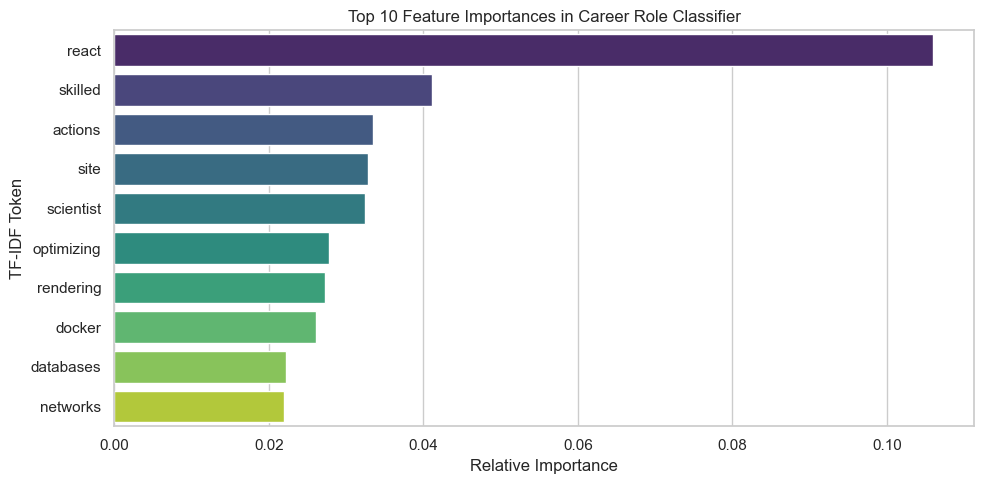

In [5]:
importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()

# Sort and plot top 10 features
indices = np.argsort(importances)[::-1][:10]
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Top 10 Feature Importances in Career Role Classifier")
plt.xlabel("Relative Importance")
plt.ylabel("TF-IDF Token")
plt.tight_layout()
os.makedirs("../models", exist_ok=True)
plt.savefig("../models/career_classifier_features.png")
plt.show()

## 5. Export Model

In [6]:
model_path = "../models/career_compass_classifier.pkl"
with open(model_path, "wb") as f:
    pickle.dump(pipeline, f)
print(f"Pipeline model exported successfully to {model_path}")

Pipeline model exported successfully to ../models/career_compass_classifier.pkl
